# Calibration check

We show patients a "risk %" in the dashboard (e.g. "73% no-show risk"). That number comes straight from `model.predict_proba()`. The question we're answering here: **when the model says 73%, do patients who get that score actually have the bad outcome about 73% of the time in reality?**

First pass (see git history / progress-log/2026-08-14.md): both raw models were meaningfully overconfident. Since then we retrained each model with `CalibratedClassifierCV` (`models/*/train.py`), producing a second saved artifact (`calibrated_v1.joblib`) alongside the original raw model. This notebook re-runs the same reliability-curve check on **both** the raw and the calibrated model, side by side, to confirm the calibration actually fixed the problem rather than just changing it.

Reminder of the method:
1. Take the held-out test patients (never seen during training, by either model).
2. Bucket them by predicted risk score.
3. For each bucket, compute the *actual* fraction who had the bad outcome.
4. Plot predicted score (x-axis) vs. actual outcome rate (y-axis).

A perfectly calibrated model hugs the diagonal line (predicted 70% -> actual 70%). Points **below** the diagonal mean the model is overconfident in that range (the dangerous direction for us -- it means predicted risk is fed into the dashboard's threshold check, and this app's alerts).

**Important note on this run**: the raw model file was retrained (on a 60% slice of the data instead of 80%, to make room for a calibration split) since the first check, so its curve here may differ slightly from before even without calibration -- see `models/*/train.py`'s comments for why.

In [1]:
import importlib.util
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.calibration import calibration_curve
from sklearn.model_selection import train_test_split

PROJECT_ROOT = Path.cwd().parent


def load_module(name: str, file_path: Path):
    """Same trick backend/main.py uses: both models have a preprocess.py
    with the same filename, so we load each under an explicit, distinct
    module name to avoid Python silently reusing one for both."""
    spec = importlib.util.spec_from_file_location(name, file_path)
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    return module


no_show_preprocess = load_module(
    "no_show_preprocess", PROJECT_ROOT / "models" / "no_show" / "preprocess.py"
)
readmission_preprocess = load_module(
    "readmission_preprocess", PROJECT_ROOT / "models" / "readmission" / "preprocess.py"
)

In [2]:
def get_held_out_labels(raw_csv_path, clean_fn, build_features_fn, csv_kwargs=None):
    """Reproduce the exact held-out test split train.py used (same
    random_state, same test_size) and return X_test/y_test -- genuinely
    unseen by both the raw and calibrated model (calibration was fit on a
    separate slice of the *training* portion, never on X_test)."""
    raw_df = pd.read_csv(raw_csv_path, **(csv_kwargs or {}))
    df_clean = clean_fn(raw_df)
    X, y = build_features_fn(df_clean)
    _, X_test, _, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
    return X_test, y_test


def predict_with(model_path, X_test):
    model = joblib.load(model_path)
    return model.predict_proba(X_test)[:, 1]


no_show_X_test, no_show_true = get_held_out_labels(
    raw_csv_path=PROJECT_ROOT / "data" / "raw" / "KaggleV2-May-2016.csv",
    clean_fn=no_show_preprocess.clean_no_show_data,
    build_features_fn=no_show_preprocess.build_features,
)
readmission_X_test, readmission_true = get_held_out_labels(
    raw_csv_path=PROJECT_ROOT / "data" / "raw" / "diabetic_data.csv",
    clean_fn=readmission_preprocess.clean_readmission_data,
    build_features_fn=readmission_preprocess.build_features,
    csv_kwargs={"na_values": ["?"]},
)

no_show_raw_probs = predict_with(PROJECT_ROOT / "models" / "no_show" / "gradient_boosting_v1.joblib", no_show_X_test)
no_show_calibrated_probs = predict_with(PROJECT_ROOT / "models" / "no_show" / "calibrated_v1.joblib", no_show_X_test)
readmission_raw_probs = predict_with(PROJECT_ROOT / "models" / "readmission" / "gradient_boosting_v1.joblib", readmission_X_test)
readmission_calibrated_probs = predict_with(PROJECT_ROOT / "models" / "readmission" / "calibrated_v1.joblib", readmission_X_test)

print(f"No-show held-out set: {len(no_show_true)} patients")
print(f"Readmission held-out set: {len(readmission_true)} patients")

/var/folders/71/ntvd5lc57cg2wzsrjb6lsb1r0000gn/T/ipykernel_46590/3513084170.py:6: DtypeWarning: Columns (0: payer_code) have mixed types. Specify dtype option on import or set low_memory=False.
  raw_df = pd.read_csv(raw_csv_path, **(csv_kwargs or {}))


No-show held-out set: 22105 patients
Readmission held-out set: 19868 patients


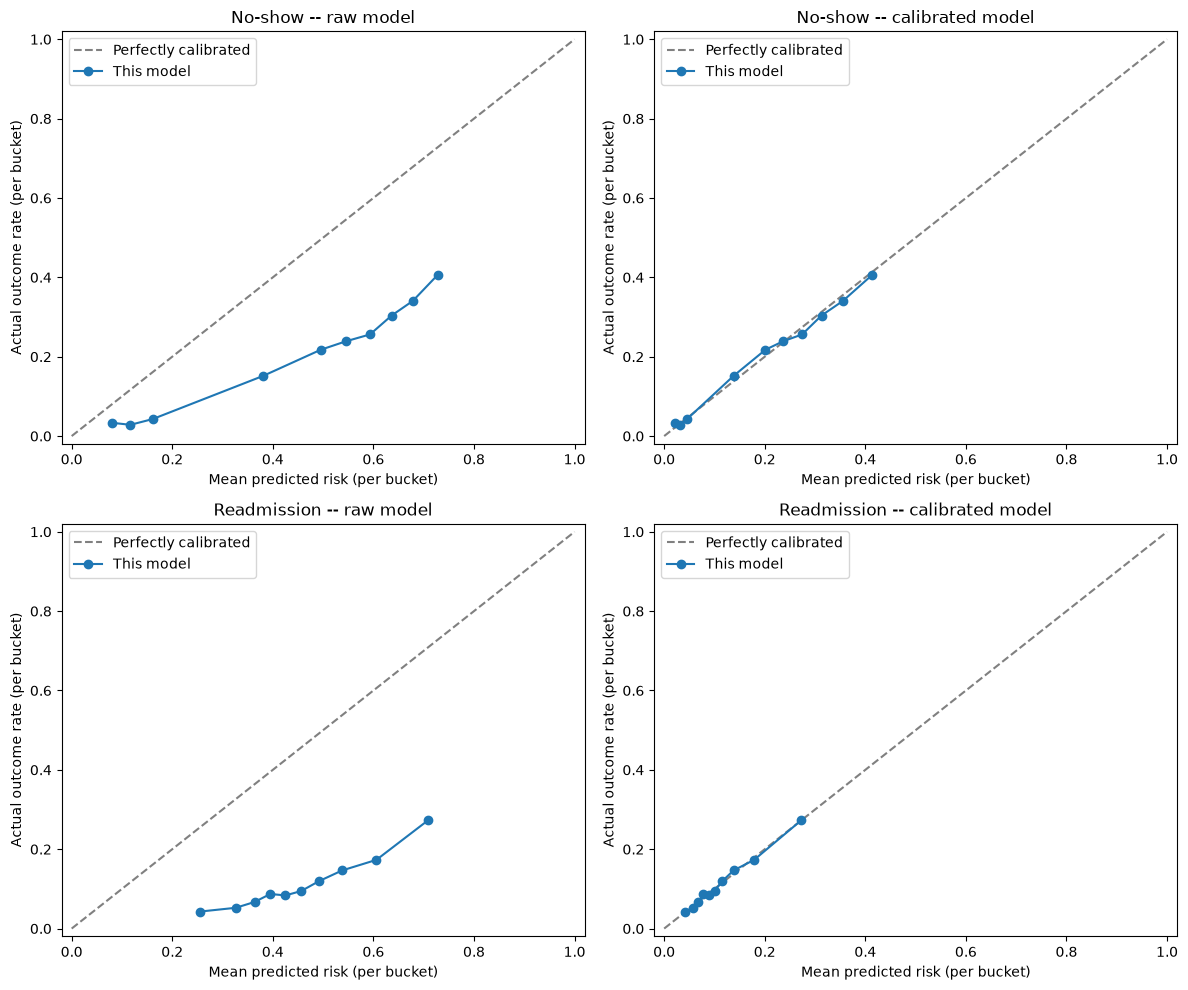

In [3]:
def plot_reliability_curve(ax, y_true, y_pred_probs, title, n_bins=10):
    actual_rate, mean_predicted = calibration_curve(
        y_true, y_pred_probs, n_bins=n_bins, strategy="quantile"
    )
    ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfectly calibrated")
    ax.plot(mean_predicted, actual_rate, marker="o", label="This model")
    ax.set_xlabel("Mean predicted risk (per bucket)")
    ax.set_ylabel("Actual outcome rate (per bucket)")
    ax.set_title(title)
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)
    ax.legend()
    return mean_predicted, actual_rate


fig, axes = plt.subplots(2, 2, figsize=(12, 10))
plot_reliability_curve(axes[0][0], no_show_true, no_show_raw_probs, "No-show -- raw model")
plot_reliability_curve(axes[0][1], no_show_true, no_show_calibrated_probs, "No-show -- calibrated model")
plot_reliability_curve(axes[1][0], readmission_true, readmission_raw_probs, "Readmission -- raw model")
plot_reliability_curve(axes[1][1], readmission_true, readmission_calibrated_probs, "Readmission -- calibrated model")
plt.tight_layout()
plt.show()

In [4]:
from sklearn.metrics import brier_score_loss

# Brier score: mean squared error between predicted probability and actual
# outcome (0 or 1) -- a single number that captures calibration quality
# (among other things). Lower is better; a well-calibrated model should
# score lower here than an overconfident one, even if ranking (AUC) is
# identical between the two.
print("Brier score (lower = more honest probabilities):")
print(f"  No-show raw:        {brier_score_loss(no_show_true, no_show_raw_probs):.4f}")
print(f"  No-show calibrated: {brier_score_loss(no_show_true, no_show_calibrated_probs):.4f}")
print(f"  Readmission raw:        {brier_score_loss(readmission_true, readmission_raw_probs):.4f}")
print(f"  Readmission calibrated: {brier_score_loss(readmission_true, readmission_calibrated_probs):.4f}")

Brier score (lower = more honest probabilities):
  No-show raw:        0.2136
  No-show calibrated: 0.1446
  Readmission raw:        0.2182
  Readmission calibrated: 0.0961


## How to read this

- Compare the two columns per row: **raw** (left) vs **calibrated** (right). The calibrated column should sit much closer to the diagonal.
- The Brier score gives a single-number summary: calibration should lower it, since Brier score rewards both correct ranking *and* honest probability values (unlike AUC, which only rewards ranking and is unaffected by calibration -- that's why AUC alone can't tell us whether calibration helped).
- If the calibrated curves now hug the diagonal (within reason -- perfect calibration is rare with real data and finite samples), that's confirmation the fix worked, and we move to the next step: re-deriving the decision thresholds against the calibrated scores, then wiring the calibrated model into the backend.